# Ejercicio 1(c) - Patrones de Demanda Espacio-Temporales en NYC

## 1. Introducción y Metodología de Procesamiento

El objetivo de este ejercicio es identificar y clasificar los patrones de demanda de taxis en Nueva York, analizando cómo varía el volumen de viajes en función de la **zona de la ciudad** y la **franja horaria**.

### ¿Cómo hemos preparado los datos y por qué?

Para estructurar este análisis, los datos históricos han sido procesados y agregados bajo tres pilares fundamentales:

1. **Agregación a nivel Zona-Hora (`pu_location_id` + `hour`):** En lugar de analizar viajes individuales o días aislados, hemos promediado la actividad a lo largo de todo el histórico para cada combinación de zona y hora. Esto nos permite mitigar el ruido estadístico de anomalías diarias (un día de lluvia extrema, un evento puntual) y nos permite extraer el comportamiento "típico" y recurrente de la ciudad.

2. **Clasificación Relativa de la Demanda (Terciles por Zona):**
   Hemos clasificado el volumen medio de viajes (`num_trips_avg`) en niveles de demanda (**Baja, Media, Alta**) calculando los terciles *de manera independiente para cada zona*.
   
   Si usáramos umbrales globales absolutos, zonas centrales como Manhattan acapararían siempre la demanda "Alta", invisibilizando los picos de actividad en zonas periféricas como Queens o Brooklyn. Al usar terciles por zona, evaluamos el rendimiento de cada barrio respecto a sí mismo, permitiéndonos encontrar el "momento punta" de cualquier rincón de la ciudad.

3. **Medida de Estabilidad (Coeficiente de Variación - CV):**
   Hemos introducido el Coeficiente de Variación ($CV = \frac{\sigma}{\mu}$) utilizando la desviación típica (`num_trips_std`). En base a este CV global, clasificamos la zona-hora como **Predecible**, **Variable** o **Volátil**.
   
   A nivel de negocio o toma de decisiones para un taxista, una demanda "Alta pero Volátil" representa un riesgo mayor que una demanda "Media pero Predecible". Esta métrica añade una capa de fiabilidad crucial para la operativa real.

El resultado es un dataset de 6.000 combinaciones zona-hora perfectamente balanceado (con una distribución casi idéntica de niveles de demanda Baja, Media y Alta).

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Carga de Datos

In [2]:
ruta_datos = "../data/aggregated/ex1c/df_demand_patterns" 
df = pd.read_parquet(ruta_datos)

# Cargar el catálogo de zonas
ruta_zonas = "../data/external/taxi_zone_lookup.csv"
df_zonas = pd.read_csv(ruta_zonas)

df = df.merge(
    df_zonas[['LocationID', 'Borough', 'Zone']], 
    left_on='pu_location_id', 
    right_on='LocationID', 
    how='left'
).drop(columns=['LocationID'])

print(f"Dataset cargado: {df.shape[0]} filas.")
display(df.head())

Dataset cargado: 6000 filas.


,hour,num_trips_avg,num_trips_std,num_trips_min,num_trips_max,num_trips_count,avg_price_mean,std_price_mean,demand_level,stability,cv,operational_priority,operational_priority_label,pu_location_id,Borough,Zone
0,0,95.730839,43.805106,38,320,1096,19.506505,12.836568,Baja,Volátil,0.457586,1,Baja,10,Queens,Baisley Park
1,1,68.035509,36.584954,30,254,1042,19.865769,12.271734,Baja,Volátil,0.537733,1,Baja,10,Queens,Baisley Park
2,2,56.309601,27.875342,30,214,927,19.421821,10.641729,Baja,Volátil,0.495037,1,Baja,10,Queens,Baisley Park
3,3,62.934743,21.565722,30,210,1088,19.666065,9.535722,Baja,Volátil,0.342668,1,Baja,10,Queens,Baisley Park
4,4,91.666971,19.632036,42,174,1096,20.081418,9.602911,Baja,Predecible,0.214167,3,Baja,10,Queens,Baisley Park


## Análisis descriptivo

### Insights del Análisis descriptivo

**1. Validación de la Demanda (Terciles Equilibrados)**
Como esperábamos por diseño, la distribución de la demanda es perfectamente equitativa (Baja: **33.5%**, Media: **33.2%**, Alta: **33.3%**). Esto confirma el éxito de nuestra estrategia de cálculo por terciles a nivel de zona. Al no usar valores absolutos, evitamos el sesgo que concentraría toda la "demanda alta" en Manhattan, logrando identificar los momentos de máxima actividad relativos a cada barrio (por ejemplo, el "pico" de actividad de un barrio periférico de Queens).

**2. La Dualidad de la Estabilidad en NYC**
Curiosamente, la variabilidad del servicio se divide de forma casi idéntica en tercios (Volátil: **34.0%**, Variable: **33.0%**, Predecible: **33.0%**). Esto revela una dinámica de movilidad dual en Nueva York: 
* Un tercio de las combinaciones zona-hora responde a rutinas férreas (probablemente desplazamientos laborales en días laborables).
* Otro tercio representa un caos operativo, donde el volumen de viajes fluctúa radicalmente (muy probablemente asociado a eventos, ocio nocturno en fines de semana o cambios meteorológicos).

**3. Foco Operativo y Rentabilidad**
La distribución de la Prioridad Operativa es la métrica más reveladora para el modelo de negocio. Prácticamente la mitad de las situaciones (**49.7%**) se clasifican como de prioridad Baja. Por el contrario, tenemos un **38.2%** de prioridad Alta y un segmento muy específico del **12.2%** de prioridad Crítica.

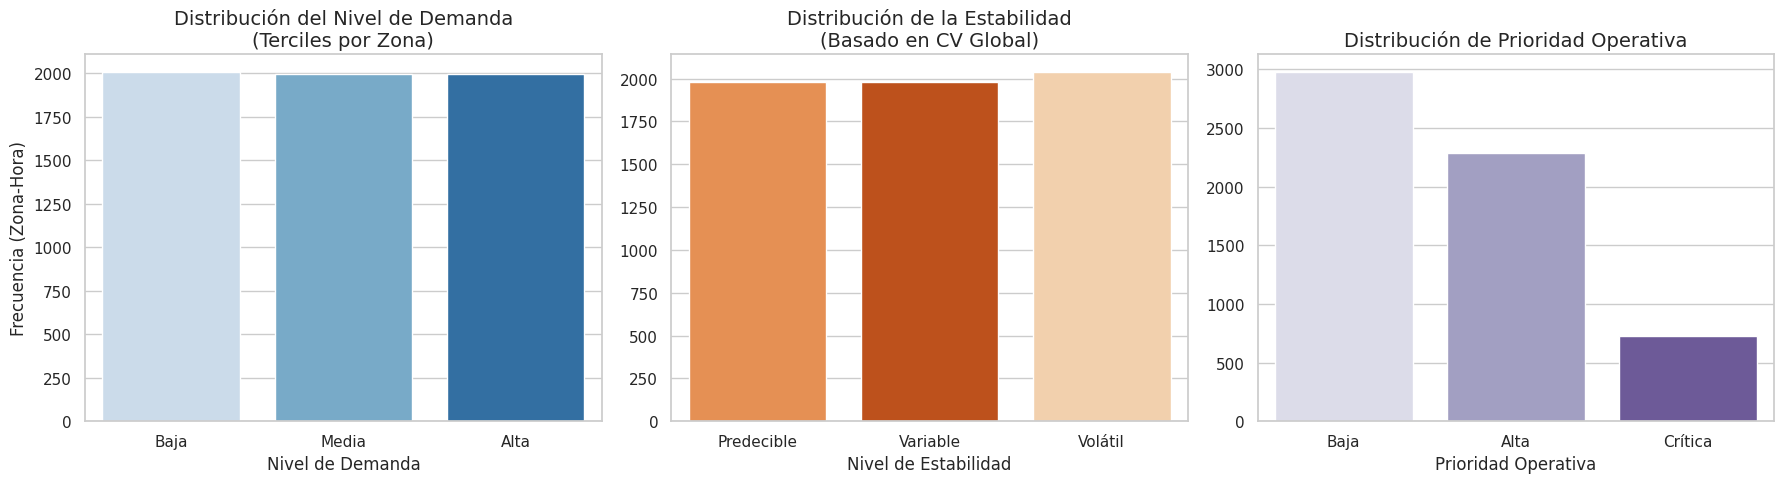

--- PROPORCIONES EXACTAS (%) ---
           Demanda (%) Estabilidad (%) Prioridad (%)
Baja              33.5               -          49.7
Alta              33.3               -          38.2
Media             33.2               -             -
Volátil              -            34.0             -
Predecible           -            33.0             -
Variable             -            33.0             -
Crítica              -               -          12.2


In [3]:
# Análisis Descriptivo: Distribución de Demanda, Estabilidad y Prioridad

# Crear una figura con 3 subgráficos en horizontal
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Definir el orden lógico de las categorías
orden_demanda = ['Baja', 'Media', 'Alta']
orden_estabilidad = ['Predecible', 'Variable', 'Volátil']

# 1. Barplot: Nivel de Demanda
sns.countplot(
    data=df, 
    x='demand_level', 
    hue='demand_level',
    order=orden_demanda, 
    palette='Blues', 
    ax=axes[0],
    legend=False
)
axes[0].set_title('Distribución del Nivel de Demanda\n(Terciles por Zona)', fontsize=14)
axes[0].set_xlabel('Nivel de Demanda', fontsize=12)
axes[0].set_ylabel('Frecuencia (Zona-Hora)', fontsize=12)

# 2. Barplot: Estabilidad (CV)
sns.countplot(
    data=df, 
    x='stability', 
    hue='stability',
    order=orden_estabilidad, 
    palette='Oranges', 
    ax=axes[1],
    legend=False
)
axes[1].set_title('Distribución de la Estabilidad\n(Basado en CV Global)', fontsize=14)
axes[1].set_xlabel('Nivel de Estabilidad', fontsize=12)
axes[1].set_ylabel('')

# 3. Barplot: Prioridad Operativa
sns.countplot(
    data=df, 
    x='operational_priority_label', 
    hue='operational_priority_label',
    palette='Purples', 
    ax=axes[2],
    legend=False
)
axes[2].set_title('Distribución de Prioridad Operativa', fontsize=14)
axes[2].set_xlabel('Prioridad Operativa', fontsize=12)
axes[2].set_ylabel('')

# Ajustar el diseño para que no se solapen
plt.tight_layout()
plt.show()

print("--- PROPORCIONES EXACTAS (%) ---")

tabla = pd.concat([
    (df['demand_level'].value_counts(normalize=True) * 100).round(1),
    (df['stability'].value_counts(normalize=True) * 100).round(1),
    (df['operational_priority_label'].value_counts(normalize=True) * 100).round(1)
], axis=1)

tabla.columns = ['Demanda (%)', 'Estabilidad (%)', 'Prioridad (%)']

print(tabla.fillna('-'))

### Evolución Temporal

**1. El Valle Operativo de Madrugada (2:00 - 5:00)**
Los datos demuestran un colapso natural de la movilidad durante la madrugada, tocando su mínimo absoluto a las 4:00 AM con apenas **91.2** viajes de media. El mapa de calor refleja esto claramente, mostrando un bloque sólido de demanda "Baja" en esas horas. 
* *Implicación:* Esta es la ventana valle (sin coste de oportunidad) ideal para que las flotas programen mantenimientos, repostajes/recargas de vehículos o cambios de turno de los conductores.

**2. El "Golden Peak" de la Tarde/Noche (17:00 - 20:00)**
La ciudad experimenta su máxima tensión de movilidad en el bloque de tarde, cruzando el final de la jornada laboral con el inicio de la actividad de ocio/cenas. El pico absoluto se alcanza a las 18:00 (**357.6** viajes de media, casi un 400% más que en la madrugada). En el mapa de calor, la etiqueta de demanda "Alta" domina por completo desde las 15:00 hasta las 20:00.
* *Implicación:* Este es el momento crítico de facturación. La incapacidad de absorber esta demanda genera frustración en el usuario y pérdida de ingresos.

**3. La Estabilidad del Mediodía (10:00 - 14:00)**
A diferencia del pico matutino (8:00 - 9:00) y el gran pico vespertino, las horas centrales del día presentan un volumen de viajes estable y constante. El mapa de calor muestra una alta concentración de etiquetas de demanda "Media". Es un periodo de transición altamente predecible.

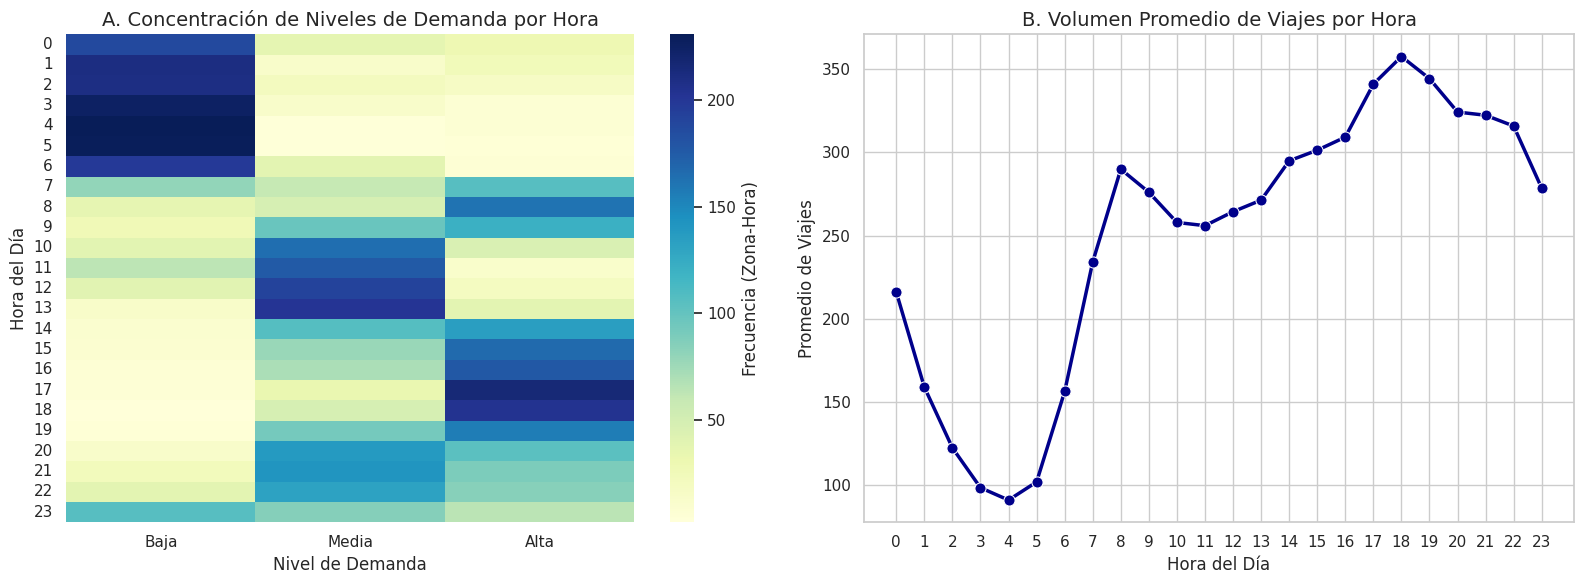

--- HORAS VALLE (Menor volumen medio de viajes) ---
hour
4     91.2
3     98.6
5    102.1
2    122.5
Name: num_trips_avg, dtype: Float64

--- HORAS PICO (Mayor volumen medio de viajes) ---
hour
18    357.6
19    344.3
17    341.0
20    324.2
Name: num_trips_avg, dtype: Float64


In [4]:
# Evolución Temporal: Demanda a lo largo del día

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Heatmap de Niveles de Demanda por Hora ---
pivot_demanda = df.pivot_table(
    index="hour",
    columns="demand_level",
    aggfunc="size",
    fill_value=0
)

# Ordenamos las columnas de forma lógica para el heatmap
pivot_demanda = pivot_demanda[['Baja', 'Media', 'Alta']]

sns.heatmap(
    pivot_demanda, 
    cmap="YlGnBu", 
    ax=axes[0], 
    cbar_kws={'label': 'Frecuencia (Zona-Hora)'}
)
axes[0].set_title('A. Concentración de Niveles de Demanda por Hora', fontsize=14)
axes[0].set_xlabel('Nivel de Demanda', fontsize=12)
axes[0].set_ylabel('Hora del Día', fontsize=12)
# Aseguramos que se vean las 24 horas en el eje Y
axes[0].set_yticks([i + 0.5 for i in range(24)])
axes[0].set_yticklabels(range(24), rotation=0)

# --- Gráfico B: Línea de Demanda Media por Hora ---
# Calculamos la media de viajes por hora
demanda_media = df.groupby("hour")["num_trips_avg"].mean()

sns.lineplot(
    x=demanda_media.index, 
    y=demanda_media.values, 
    marker="o", 
    color="darkblue",
    linewidth=2.5,
    markersize=8,
    ax=axes[1]
)
axes[1].set_title('B. Volumen Promedio de Viajes por Hora', fontsize=14)
axes[1].set_xlabel('Hora del Día', fontsize=12)
axes[1].set_ylabel('Promedio de Viajes', fontsize=12)
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

print("--- HORAS VALLE (Menor volumen medio de viajes) ---")
print(demanda_media.nsmallest(4).round(1))

print("\n--- HORAS PICO (Mayor volumen medio de viajes) ---")
print(demanda_media.nlargest(4).round(1))

### Patrones por zona (heterogeneidad espacial)

**1. El monopolio de los Aeropuertos (Nodos de Transporte)**
JFK y LaGuardia lideran de forma aplastante el volumen de la ciudad, superando los **1.300 viajes medios**. Como observamos en su evolución diaria, tienen un ecosistema propio: su demanda no obedece al típico horario de oficina, sino que crece de forma sostenida a lo largo del día y se mantiene muy alta hasta bien entrada la noche, guiada por la programación de vuelos.
* *Implicación:* Los aeropuertos son "agujeros negros" de demanda. Requieren una flota cautiva o un sistema de asignación de colas independiente al del resto de la ciudad.

**2. El latido de los Negocios (Midtown Center)**
La zona de *Midtown Center* ocupa el tercer lugar (1.029 viajes medios), pero su comportamiento es el clásico de un hub financiero/comercial. Su curva muestra un despertar agresivo por la mañana, un valle al mediodía y un pico explosivo por la tarde (cuando las oficinas cierran), para desplomarse rápidamente durante la noche cuando el barrio se vacía.

**3. El relevo del Ocio y lo Residencial**
El resto del Top 10 nos confirma cómo se mueve el dinero en la ciudad tras la jornada laboral. Zonas puramente de ocio y restauración nocturna (*Times Sq/Theatre District*, *East Village*, *East Chelsea*) conviven en volumen con los grandes bloques residenciales (*Upper East Side South/North*). Esto demuestra una migración pendular: los usuarios viajan de las zonas de negocio a las de ocio, y finalmente a las residenciales.

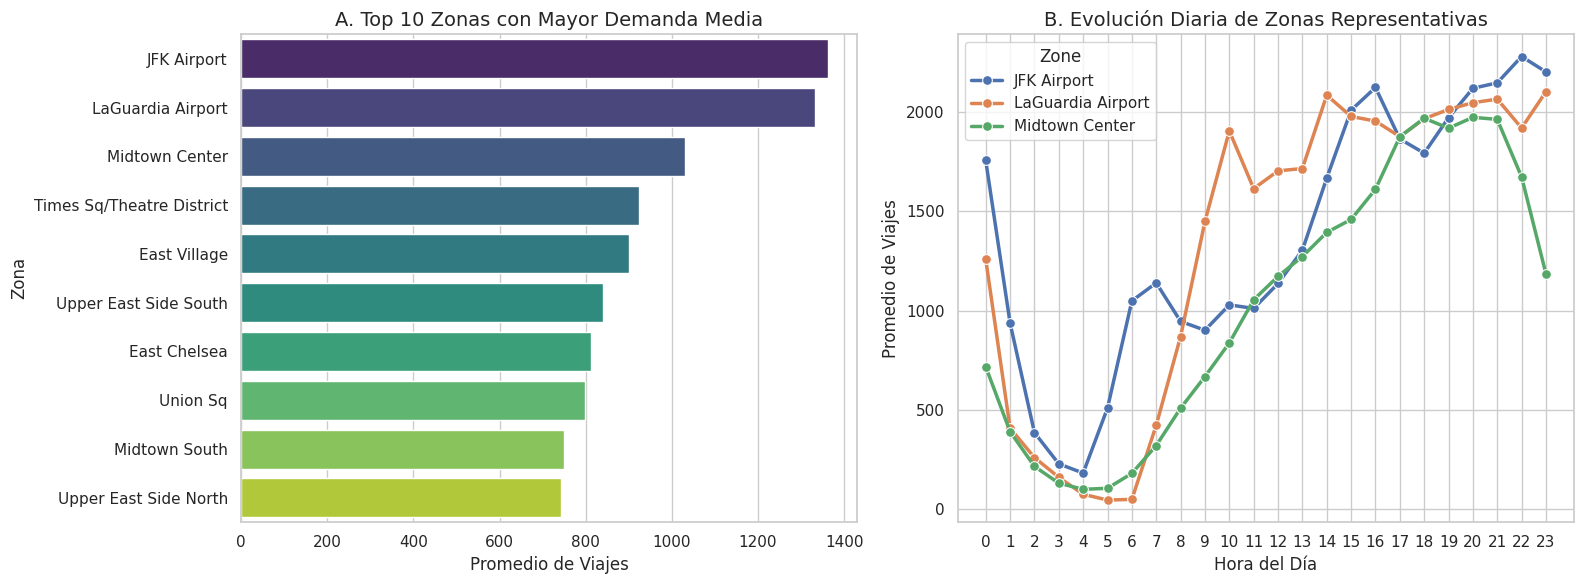

--- TOP 10 ZONAS POR VOLUMEN MEDIO ---
Zone
JFK Airport                  1362.9
LaGuardia Airport            1331.7
Midtown Center               1029.5
Times Sq/Theatre District     923.1
East Village                  900.8
Upper East Side South         840.3
East Chelsea                  812.6
Union Sq                      798.7
Midtown South                 749.2
Upper East Side North         742.9
Name: num_trips_avg, dtype: Float64


In [5]:
# Heterogeneidad Espacial: Patrones por Zona

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Top 10 Zonas con más demanda ---
# Agrupamos por el nombre de la zona para que el gráfico sea interpretable
top_10_zonas = df.groupby("Zone")["num_trips_avg"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_10_zonas.values, 
    y=top_10_zonas.index, 
    hue=top_10_zonas.index,
    palette="viridis", 
    ax=axes[0],
    legend=False
)
axes[0].set_title('A. Top 10 Zonas con Mayor Demanda Media', fontsize=14)
axes[0].set_xlabel('Promedio de Viajes', fontsize=12)
axes[0].set_ylabel('Zona', fontsize=12)

# --- Gráfico B: Evolución temporal de zonas representativas ---
# Se extrae las 3 zonas con más volumen del Top 10.
zonas_representativas = top_10_zonas.index[:3].tolist() 
df_zonas = df[df['Zone'].isin(zonas_representativas)]

sns.lineplot(
    data=df_zonas, 
    x="hour", 
    y="num_trips_avg", 
    hue="Zone", 
    marker="o", 
    linewidth=2.5,
    markersize=7,
    ax=axes[1]
)
axes[1].set_title('B. Evolución Diaria de Zonas Representativas', fontsize=14)
axes[1].set_xlabel('Hora del Día', fontsize=12)
axes[1].set_ylabel('Promedio de Viajes', fontsize=12)
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

print("--- TOP 10 ZONAS POR VOLUMEN MEDIO ---")
print(top_10_zonas.round(1))

### Demanda vs Estabilidad

Al cruzar el Nivel de Demanda con nuestro índice de Estabilidad (basado en el CV), descubrimos la verdadera anatomía del riesgo operativo en Nueva York.

**1. El "Core" del Negocio (Alta Demanda + Predecible)**
Existen **730 combinaciones** de zona-hora que son de demanda Alta y comportamiento Predecible. Estos son nuestros **"Hotspots Fiables"**. 
* *Implicación:* Son el motor económico base de la ciudad (rutinas de oficina, nudos de transporte principales).

**2. El Gran Reto Algorítmico (Alta Demanda + Volátil)**
El dato más crítico de la matriz son las **544 combinaciones** de demanda Alta pero Volátil. Son momentos donde la ciudad "estalla" en demanda, pero no de forma consistente todos los días (eventos deportivos, tormentas imprevistas, picos de ocio anómalos).
* *Implicación:* Aquí es donde las empresas de la competencia fallan, dejando usuarios sin coche o aplicando tarifas dinámicas abusivas.

**3. El "Ruido" Operativo (Baja Demanda + Volátil)**
La gran mayoría de la volatilidad de la ciudad (**1.068 casos**) ocurre en escenarios de Baja demanda. Esto tiene sentido matemático (un par de viajes extra en una zona vacía disparan la varianza temporal), pero operativamente es una trampa.
* *Implicación:* Enviar conductores a estas zonas guiándose por "picos repentinos" es un error que genera kilómetros en vacío (coste puro). Se pueden considerar como falsos positivos.

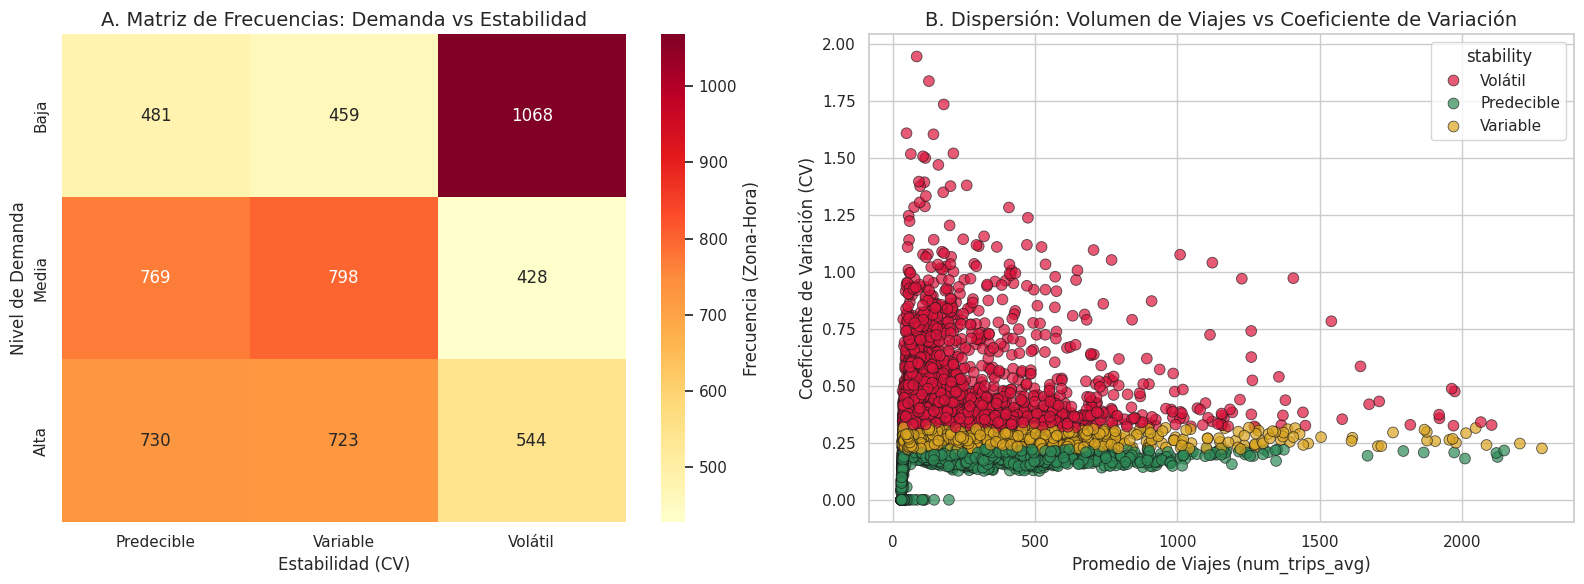

--- MATRIZ CRUZADA (DEMANDA VS ESTABILIDAD) ---
stability     Predecible  Variable  Volátil
demand_level                               
Baja                 481       459     1068
Media                769       798      428
Alta                 730       723      544


In [6]:
# Demanda vs Estabilidad: Fiabilidad del Servicio

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Heatmap de Demanda vs Estabilidad ---
# Creamos la tabla cruzada
crosstab_demanda_estabilidad = pd.crosstab(
    df["demand_level"], 
    df["stability"]
)

# Ordenamos filas y columnas de forma lógica de menor a mayor
crosstab_demanda_estabilidad = crosstab_demanda_estabilidad.reindex(
    index=['Baja', 'Media', 'Alta'], 
    columns=['Predecible', 'Variable', 'Volátil']
)

# Heatmap con anotaciones (números dentro de las celdas)
sns.heatmap(
    crosstab_demanda_estabilidad, 
    annot=True, 
    fmt="d", 
    cmap="YlOrRd", 
    cbar_kws={'label': 'Frecuencia (Zona-Hora)'},
    ax=axes[0]
)
axes[0].set_title('A. Matriz de Frecuencias: Demanda vs Estabilidad', fontsize=14)
axes[0].set_xlabel('Estabilidad (CV)', fontsize=12)
axes[0].set_ylabel('Nivel de Demanda', fontsize=12)

# --- Gráfico B: Scatter Plot (Volumen vs Variabilidad) ---
sns.scatterplot(
    data=df, 
    x="num_trips_avg", 
    y="cv", 
    hue="stability", 
    palette={"Predecible": "seagreen", "Variable": "goldenrod", "Volátil": "crimson"},
    alpha=0.7,
    edgecolor="k",
    s=60,
    ax=axes[1]
)
axes[1].set_title('B. Dispersión: Volumen de Viajes vs Coeficiente de Variación', fontsize=14)
axes[1].set_xlabel('Promedio de Viajes (num_trips_avg)', fontsize=12)
axes[1].set_ylabel('Coeficiente de Variación (CV)', fontsize=12)

plt.tight_layout()
plt.show()

print("--- MATRIZ CRUZADA (DEMANDA VS ESTABILIDAD) ---")
print(crosstab_demanda_estabilidad)

### Prioridad operacional

La etiqueta de Prioridad Operacional traduce todo el análisis estadístico previo a una métrica de decisión directa para la plataforma. 

**1. Dimensionando el "Terreno de Juego"**
De todas las combinaciones posibles de zona-hora en la ciudad, solo **730 casos (12.2%)** caen en la categoría "Crítica" (Alta demanda + Alta volatilidad), frente a los **2.980 casos** de prioridad Baja. Esto demuestra que la ciudad no es un caos constante; el problema está altamente concentrado.

**2. El Desfase entre "Hora Pico" y "Hora Crítica"**
Este es el descubrimiento más importante del análisis descriptivo. Anteriormente observamos que el volumen máximo de viajes puros ocurre a las 18:00 y 19:00. Sin embargo, la **máxima criticidad operativa se adelanta a las 17:00 (122 zonas críticas)**, con un bloque altamente inestable que se gesta desde las 14:00 (98 zonas críticas). 
* *Implicación:* La transición de la tarde (salidas de colegios, fin de jornadas tempranas, recados de última hora) genera escenarios mucho más impredecibles que la hora punta de la noche, que aunque masiva, es más estable y rutinaria.

**Conclusión Final de Negocio:**
Un sistema de gestión de flotas tradicional tiende a basarse en promedios históricos, lo que suele llevar a concentrar la oferta en torno a las 19:00. Sin embargo, para ese momento la oportunidad ya está parcialmente perdida. Un enfoque basado en datos permite identificar que la ventana clave de rentabilidad se sitúa entre las 15:00 y las 17:00. Anticiparse a ese periodo, posicionando la flota en las zonas con mayor volatilidad antes de que aumente la demanda, contribuye a reducir los tiempos de espera del usuario y a maximizar el tiempo efectivo de servicio de los conductores.

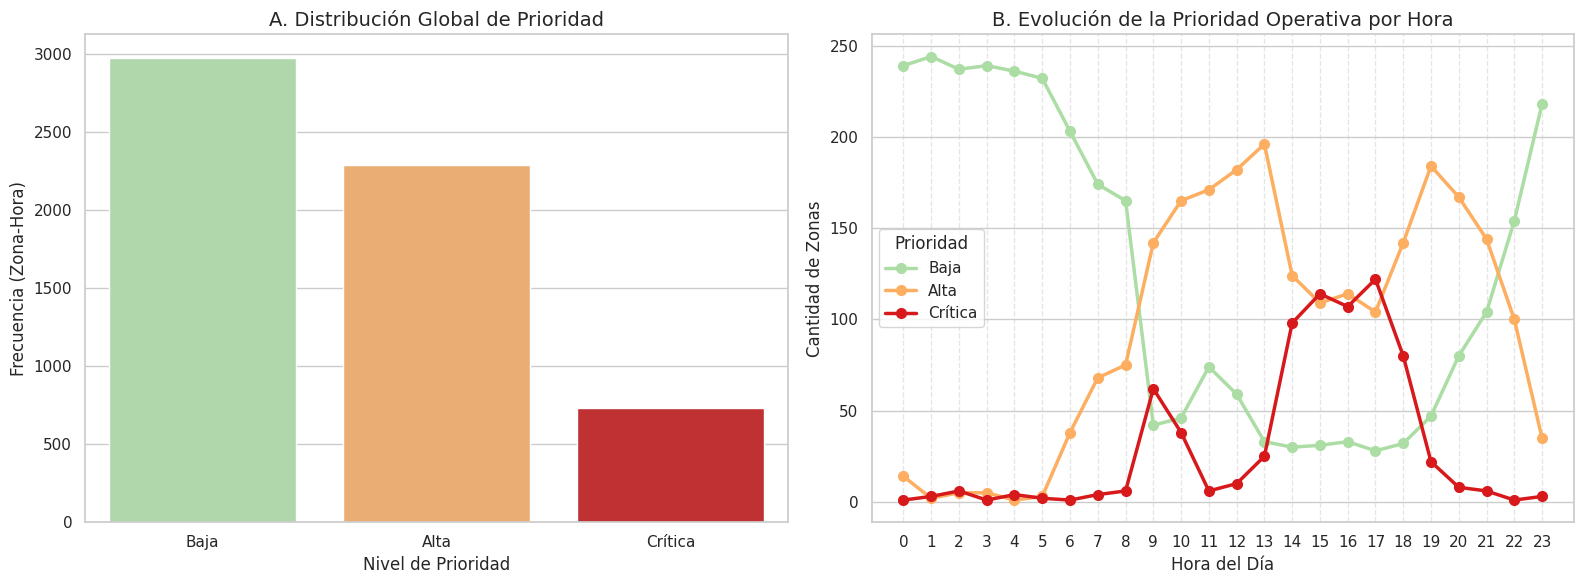

--- DISTRIBUCIÓN DE PRIORIDAD ---
operational_priority_label
Baja       2980
Alta       2290
Crítica     730
Name: count, dtype: int64

--- TOP 5 HORAS CON MÁS ZONAS CRÍTICAS ---
hour
17    122
15    114
16    107
14     98
18     80
Name: Crítica, dtype: int64


In [7]:
# Prioridad Operacional: El Foco de Negocio

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Distribución Global de Prioridad ---
# Definimos el orden lógico y colores tipo "semáforo"
orden_prioridad = ['Baja', 'Alta', 'Crítica']
colores_prioridad = ['#abdda4', '#fdae61', '#d7191c'] # Verde, Naranja, Rojo

sns.countplot(
    data=df, 
    x='operational_priority_label', 
    hue='operational_priority_label',
    order=orden_prioridad,
    palette=colores_prioridad,
    ax=axes[0],
    legend=False
)
axes[0].set_title('A. Distribución Global de Prioridad', fontsize=14)
axes[0].set_xlabel('Nivel de Prioridad', fontsize=12)
axes[0].set_ylabel('Frecuencia (Zona-Hora)', fontsize=12)

# --- Gráfico B: Prioridad por Hora ---
# Creamos la tabla cruzada
crosstab_hora_prioridad = pd.crosstab(
    df["hour"], 
    df["operational_priority_label"]
)

# Filtramos y ordenamos para asegurar que coinciden los colores
cols_presentes = [col for col in orden_prioridad if col in crosstab_hora_prioridad.columns]
crosstab_hora_prioridad = crosstab_hora_prioridad[cols_presentes]

# Dibujamos las líneas
crosstab_hora_prioridad.plot(
    kind='line', 
    marker='o',
    linewidth=2.5,
    markersize=7,
    color=[colores_prioridad[orden_prioridad.index(col)] for col in cols_presentes],
    ax=axes[1]
)
axes[1].set_title('B. Evolución de la Prioridad Operativa por Hora', fontsize=14)
axes[1].set_xlabel('Hora del Día', fontsize=12)
axes[1].set_ylabel('Cantidad de Zonas', fontsize=12)
axes[1].set_xticks(range(24))
axes[1].legend(title='Prioridad')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("--- DISTRIBUCIÓN DE PRIORIDAD ---")
print(df["operational_priority_label"].value_counts())

print("\n--- TOP 5 HORAS CON MÁS ZONAS CRÍTICAS ---")
if 'Crítica' in crosstab_hora_prioridad.columns:
    print(crosstab_hora_prioridad['Crítica'].nlargest(5))
else:
    print("No hay zonas etiquetadas como 'Crítica' en el dataset.")

## clustering sobre comportamiento temporal

Hasta ahora hemos analizado la ciudad como un todo o por zonas individuales. Sin embargo, para una gestión de flota eficiente, no podemos tratar a las 263 zonas de forma aislada. El objetivo de este clustering es identificar "Arquetipos de Barrios".

Al normalizar los datos, eliminamos la diferencia de volumen (que una zona tenga 1.000 viajes y otra 10) y nos centramos exclusivamente en la forma de su demanda. Queremos responder a: ¿Esta zona despierta por la mañana? ¿Es una zona de tarde? ¿O es un nodo que nunca duerme?

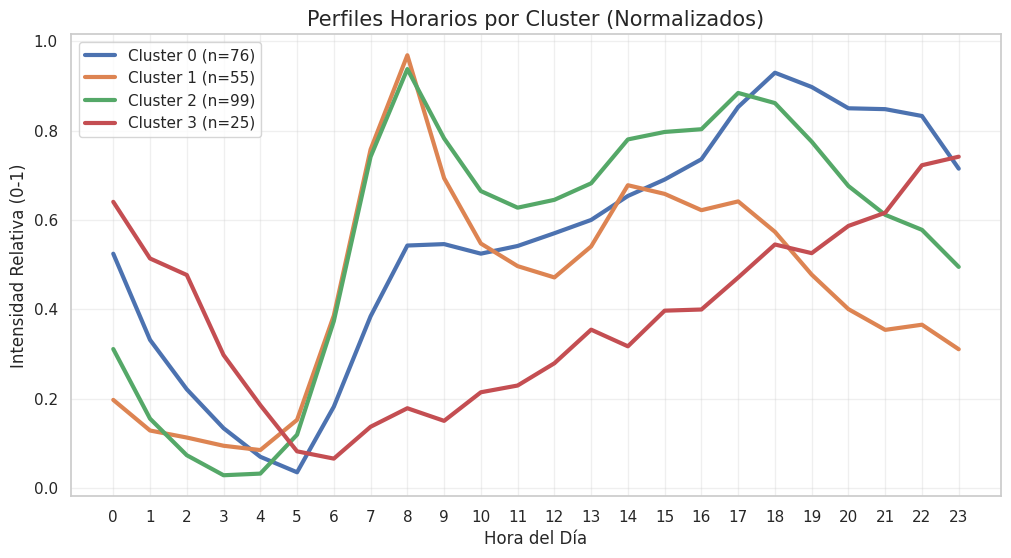

In [ ]:
# 1. Preparación de la Matriz Zona-Hora
# Creamos la matriz: filas = Zonas, columnas = Horas, valores = Promedio viajes
cluster_matrix = df.pivot_table(
    index="Zone", 
    columns="hour", 
    values="num_trips_avg", 
    fill_value=0
)

# 2. Normalización (Escalado por Fila)
# Queremos que todas las zonas tengan un máximo de 1 y mínimo de 0 
# para comparar "formas de curva" y no "volúmenes de viajes".
scaler = MinMaxScaler()
cluster_matrix_std = scaler.fit_transform(cluster_matrix.T).T
cluster_matrix_std = pd.DataFrame(cluster_matrix_std, index=cluster_matrix.index, columns=cluster_matrix.columns)

# 3. Ejecución de K-Means
# Probamos con 4 clusters para identificar patrones claros (Ocio, Negocio, Aeropuerto, Residencial)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(cluster_matrix_std)

# Añadimos el cluster a nuestra matriz y al dataframe original para después
cluster_matrix['cluster'] = clusters
cluster_mapping = cluster_matrix[['cluster']]

# 4. Visualización de los Perfiles (Centroides)
plt.figure(figsize=(12, 6))
for i in range(n_clusters):
    cluster_data = cluster_matrix_std[clusters == i]
    plt.plot(cluster_data.mean(axis=0), label=f'Cluster {i} (n={len(cluster_data)})', linewidth=3)

plt.title('Perfiles Horarios por Cluster (Normalizados)', fontsize=15)
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Intensidad Relativa (0-1)', fontsize=12)
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
# Calculamos volumen medio por zona
zona_volumen = df.groupby("Zone")["num_trips_avg"].mean()

# Unimos con los clusters
resumen = cluster_mapping.join(zona_volumen)

for i in range(n_clusters):
    cluster_i = resumen[resumen["cluster"] == i]
    
    print(f"\n--- Cluster {i} ({len(cluster_i)} zonas) ---")
    
    display(
        cluster_i
        .sort_values("num_trips_avg", ascending=False)
        .head(5)
        .round(1)
    )


--- Cluster 0 (76 zonas) ---


,cluster,num_trips_avg
Zone,,
JFK Airport,0,1362.9
LaGuardia Airport,0,1331.7
Midtown Center,0,1029.5
Times Sq/Theatre District,0,923.1
East Chelsea,0,812.6



--- Cluster 1 (55 zonas) ---


,cluster,num_trips_avg
Zone,,
Richmond Hill,1,231.1
Saint Albans,1,220.0
Van Cortlandt Village,1,197.1
Morrisania/Melrose,1,193.8
Baisley Park,1,178.0



--- Cluster 2 (99 zonas) ---


,cluster,num_trips_avg
Zone,,
Upper East Side South,2,840.3
Upper East Side North,2,742.9
East New York,2,577.2
Upper West Side South,2,565.1
Lenox Hill West,2,539.5



--- Cluster 3 (25 zonas) ---


,cluster,num_trips_avg
Zone,,
East Village,3,900.8
West Village,3,689.1
Lower East Side,3,648.7
Bushwick South,3,579.0
Williamsburg (North Side),3,543.1


Tras cruzar los clusters con las zonas reales, identificamos los 4 pilares de la movilidad en NYC:

- **Cluster 0: Centros Neurálgicos y Grandes Conectores (76 zonas)**

    - **Zonas representativas**: JFK Airport, LaGuardia Airport, Midtown Center, Times Square.

    - **Perfil**: Es el "corazón" de la actividad. Son zonas de volumen masivo que no descansan. Combinan el flujo constante de los aeropuertos con el bullicio turístico y de negocios de Midtown.

- **Cluster 1: Periferia y Barrios de Baja Densidad (55 zonas)**

    - **Zonas representativas**: Richmond Hill, Saint Albans, Morrisania (Queens y Bronx).

    - **Perfil**: Son zonas con volúmenes mucho más bajos (num_trips_avg entre 170-230). Representan barrios periféricos donde el taxi/VTC se usa de forma más esporádica o para trayectos muy específicos (posiblemente conexiones con el metro).

- **Cluster 2: El Cinturón Residencial y de "Commuters" (99 zonas)**

    - **Zonas representativas**: Upper East Side (North/South), Upper West Side, East New York.

    - **Perfil**: Es el grupo más grande. Representa donde vive la gente que trabaja en el Cluster 0. Su comportamiento es el más predecible: el coche se pide para salir de casa (mañana) y para volver (tarde).

- **Cluster 3: Distritos de Ocio y Vida Nocturna (25 zonas)**

    - **Zonas representativas**: East Village, West Village, Lower East Side, Bushwick South.

    - **Perfil**: Zonas de alta densidad pero con un ritmo "tardío". El volumen es alto (900 viajes en East Village), pero sabemos por su perfil que este volumen explota cuando el resto de la ciudad empieza a dormir.

### El Mapa Estratégico: Geografía de la Oportunidad

El mapa coroplético confirma que el comportamiento de la demanda en Nueva York no es aleatorio, sino que responde a una **lógica urbanística y funcional** perfectamente definida. 

**¿Qué estamos viendo en el mapa?**

1. **La "Isla de la Actividad" (Cluster 0):** Manhattan aparece dominado por el color del Cluster 0, extendiéndose desde el Midtown hacia los dos grandes aeropuertos. Esta "columna vertebral" de la ciudad es el área de máxima facturación y requiere una presencia de flota constante.

2. **El Cinturón de Dormitorios (Cluster 2):** Observamos cómo las zonas residenciales (Upper East/West Side y partes de Brooklyn) rodean los centros de negocio. Este patrón indica que la flota debe "fluir" hacia el centro por la mañana y "replegarse" hacia estos barrios por la tarde.

3. **Enclaves de Ocio (Cluster 3):** Los focos de vida nocturna en el Village y Williamsburg aparecen como "islas" de alta rentabilidad nocturna. 

4. **Zonas de Baja Prioridad (Cluster 1):** La periferia muestra una demanda esparcida y menos estructurada.

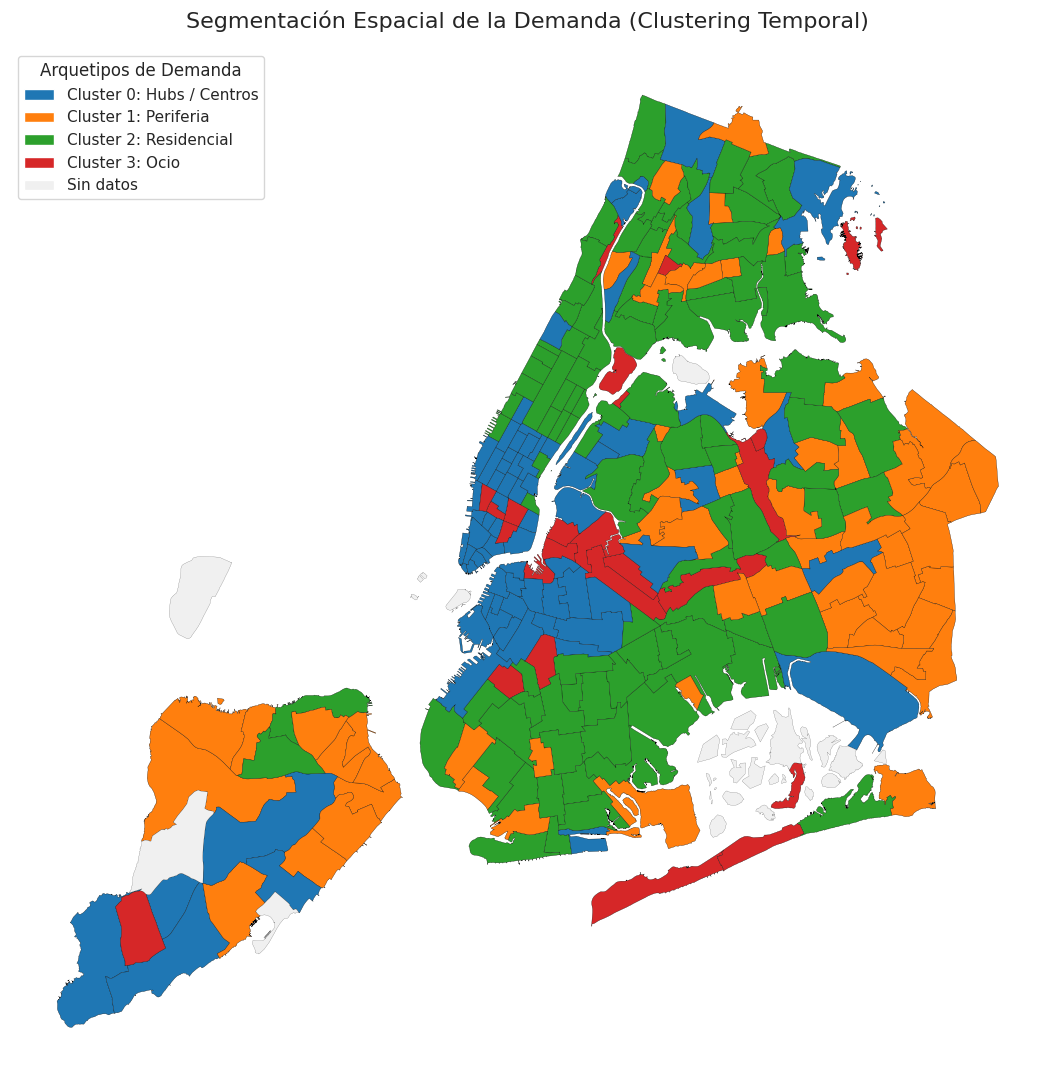

In [10]:
ruta_shp = "../data/external/taxi_zones/taxi_zones.shp" 
gdf_zonas = gpd.read_file(ruta_shp)

# Aseguramos el merge usando el nombre de la zona
gdf_mapa = gdf_zonas.merge( 
    cluster_mapping, 
    left_on='zone', 
    right_index=True,
    how='left' 
)

# Mapeo de clusters a nombres
cluster_labels = {
    0: "Hubs / Centros",
    1: "Periferia",
    2: "Residencial",
    3: "Ocio"
}

# Colores consistentes con tab10
cmap = plt.get_cmap("tab10")
colores = {i: cmap(i) for i in cluster_labels.keys()}

# Separar datos
gdf_con_cluster = gdf_mapa[gdf_mapa["cluster"].notna()].copy()
gdf_sin_cluster = gdf_mapa[gdf_mapa["cluster"].isna()].copy()

# Asignar colores SOLO a los que tienen cluster
gdf_con_cluster["color"] = gdf_con_cluster["cluster"].map(colores)

# --- Plot ---
fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# 1. Zonas con cluster
gdf_con_cluster.plot(
    color=gdf_con_cluster["color"],
    ax=ax,
    edgecolor="black",
    linewidth=0.2
)

# 2. Zonas sin datos
gdf_sin_cluster.plot(
    ax=ax,
    color="#f0f0f0",
    edgecolor="black",
    linewidth=0.1
)

# --- Leyenda personalizada ---
legend_elements = [
    Patch(facecolor=colores[i], label=f"Cluster {i}: {cluster_labels[i]}")
    for i in cluster_labels
]

legend_elements.append(
    Patch(facecolor="#f0f0f0", label="Sin datos")
)

ax.legend(
    handles=legend_elements,
    title="Arquetipos de Demanda",
    loc="upper left",
    frameon=True
)

plt.title(
    "Segmentación Espacial de la Demanda (Clustering Temporal)",
    fontsize=16,
    pad=15
)

ax.set_axis_off()

plt.tight_layout()
plt.show()